# Belief-matching vs CM vs Regularized CM on Google's experimental surface-code data

We compare three matching decoders — **MWPM**, **Correlated Matching (CM, $\alpha=1$)** and
**Regularized CM (RCM, $\alpha<1$)** — against Google's own **belief-matching** and
**tensor-network** decoders, on real Sycamore data.

**Two datasets, one of which fits the request:**

* **`google_qec3v5_experiment_data`** — the *standard rotated (CSS) surface code* from the 2023
  Sycamore paper. Each experiment ships **Spitz-calibrated (pairwise $p_{ij}$), cross-validated
  DEMs** (`pij_from_even_for_odd.dem` / `pij_from_odd_for_even.dem` — weights reweighted from the
  observed pairwise detector correlations; *not* DGR, *not* the RL-optimized prior of Sivak et al.,
  which exists only for the XZZX `google_105Q` dataset) and pre-computed predictions from
  `pymatching`, `correlated_matching`, `belief_matching` and `tensor_network_contraction`. This is
  the clean comparison and it is our main analysis.
* **`google_105Q_surface_code_d3_d5_d7`** — the **XZZX** surface code (per its README), with decoder
  pathways `correlated_matching`, `harmony`, `libra` but **no belief-matching**. It is *not* the
  standard rotated code and lacks a BM baseline, so the requested BM-vs-CM-vs-RCM comparison does
  not apply cleanly; we explain this and show only what is meaningful.

**On the decomposition / coordinates.** The qec3v5 circuits *do* carry detector coordinates, but the
project's coordinate-aware decomposer (`decompose_errors_for_stim_surface_code_coords`) fails on
Google's layout (a convention mismatch, not missing coordinates). This is a non-issue: Google ships
**already-decomposed, data-calibrated** DEMs, which is exactly what one should use on experimental
data — so CM/RCM run on those directly. (Stim's built-in `decompose_errors=True` also works if an
uncalibrated DEM is ever needed.)

Near the experimental error rates the code operates **close to threshold**, where our theory says the
optimal $\alpha^{*}\to1$; so we sweep **high** $\alpha$ values for RCM.

In [1]:
%matplotlib inline
import os, sys, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "figures_generation" else os.getcwd()
sys.path.insert(0, os.path.join(ROOT, "src"))
import stim, pymatching

plt.rcParams.update({"font.size": 11, "figure.dpi": 110, "mathtext.fontset": "cm",
                     "axes.grid": True, "grid.alpha": 0.3})
FIG = os.path.join(ROOT, "plots", "figures"); os.makedirs(FIG, exist_ok=True)
QEC3 = os.path.join(ROOT, "google_qec3v5_experiment_data")
D105 = os.path.join(ROOT, "google_105Q_surface_code_d3_d5_d7", "google_105Q_surface_code_d3_d5_d7")
AVAILABLE_ROUNDS = list(range(1, 26, 2))     # 1,3,5,...,25


def _read(path, ndet, nobs):
    fmt = "01" if path.endswith(".01") else "b8"
    return np.asarray(stim.read_shot_data_file(path=path, format=fmt,
                      num_detectors=ndet, num_observables=nobs))


def load_qec3(d, rounds, basis="Z", center="5_5"):
    "Load a qec3v5 experiment: circuit, detection events, actual obs, Google predictions, calibrated DEMs."
    ddir = os.path.join(QEC3, f"surface_code_b{basis}_d{d}_r{rounds:02d}_center_{center}")
    circ = stim.Circuit.from_file(os.path.join(ddir, "circuit_noisy.stim"))
    nd, no = circ.num_detectors, circ.num_observables
    dets = _read(os.path.join(ddir, "detection_events.b8"), nd, 0).astype(bool)
    act = _read(os.path.join(ddir, "obs_flips_actual.01"), 0, no).astype(np.uint8).reshape(-1)
    N = len(act)
    google = {}
    for key, fn in [("pymatching", "obs_flips_predicted_by_pymatching.01"),
                    ("corr", "obs_flips_predicted_by_correlated_matching.01"),
                    ("bm", "obs_flips_predicted_by_belief_matching.01"),
                    ("tn", "obs_flips_predicted_by_tensor_network_contraction.01")]:
        p = os.path.join(ddir, fn)
        if os.path.exists(p):
            google[key] = _read(p, 0, no).astype(np.uint8).reshape(-1)[:N]
    dem_odd = stim.DetectorErrorModel.from_file(os.path.join(ddir, "pij_from_even_for_odd.dem"))
    dem_even = stim.DetectorErrorModel.from_file(os.path.join(ddir, "pij_from_odd_for_even.dem"))
    return dict(dets=dets, act=act, google=google, dem_odd=dem_odd, dem_even=dem_even, N=N)


def decode_cv(ex, alpha, corr):
    "Cross-validated fork decode: odd shots use the even-calibrated DEM and vice versa (leakage-free)."
    dets, N = ex["dets"], ex["N"]
    pred = np.zeros(N, np.uint8)
    idx = np.arange(N); even = idx % 2 == 0; odd = ~even
    for mask, dem in ((odd, ex["dem_odd"]), (even, ex["dem_even"])):
        m = pymatching.Matching.from_detector_error_model(dem, enable_correlations=corr)
        if corr:
            pred[mask] = np.asarray(m.decode_batch(dets[mask], enable_correlations=True, alpha=alpha)).reshape(-1)
        else:
            pred[mask] = np.asarray(m.decode_batch(dets[mask])).reshape(-1)
    return pred


def ler(pred, act):
    n = len(act); e = int(np.sum(pred != act)); p = e / n
    return p, e, float(np.sqrt(p * (1 - p) / n))


print("ROOT =", ROOT, "| qec3v5 exists:", os.path.isdir(QEC3), "| 105Q exists:", os.path.isdir(D105))

ROOT = C:\Users\cesar\Documents\Python\master-thesis\Master-thesis-RL-QEC | qec3v5 exists: True | 105Q exists: True


## 1. One experiment, all decoders ($d=5$, $Z$-memory, 5 rounds, center 5_5)

Google's calibrated cross-validated DEMs, 50 000 shots. We list our fork's **MWPM / CM($\alpha=1$) /
RCM($\alpha$ swept high)** next to Google's four pre-computed decoders. This point is **near
threshold** (MWPM LER $\sim14\%$).

In [2]:
ex = load_qec3(5, 5, "Z", "5_5")
print(f"shots = {ex['N']:,}\n")
print(f"{'decoder':<34}{'LER':>10}{'errors':>9}")
print("-" * 53)
# our fork decoders (calibrated pij, cross-validated)
for name, a, corr in [("fork MWPM", 1.0, False), ("fork CM (alpha=1)", 1.0, True)]:
    l, e, s = ler(decode_cv(ex, a, corr), ex["act"]); print(f"{name:<34}{l:>10.4e}{e:>9}")
for a in [0.95, 0.9, 0.85, 0.8, 0.7]:
    l, e, s = ler(decode_cv(ex, a, True), ex["act"]); print(f"{'fork RCM (alpha='+str(a)+')':<34}{l:>10.4e}{e:>9}")
print("-" * 53)
gn = {"pymatching": "Google MWPM", "corr": "Google correlated-matching",
      "bm": "Google belief-matching", "tn": "Google tensor-network"}
for k, nm in gn.items():
    if k in ex["google"]:
        l, e, s = ler(ex["google"][k], ex["act"]); print(f"{nm:<34}{l:>10.4e}{e:>9}")

shots = 50,000

decoder                                  LER   errors
-----------------------------------------------------


fork MWPM                         1.4158e-01     7079


fork CM (alpha=1)                 1.1846e-01     5923


fork RCM (alpha=0.95)             1.1810e-01     5905


fork RCM (alpha=0.9)              1.1822e-01     5911


fork RCM (alpha=0.85)             1.1782e-01     5891


fork RCM (alpha=0.8)              1.1764e-01     5882


fork RCM (alpha=0.7)              1.1766e-01     5883
-----------------------------------------------------
Google MWPM                       1.4376e-01     7188
Google correlated-matching        1.2516e-01     6258
Google belief-matching            1.0724e-01     5362
Google tensor-network             1.0216e-01     5108


## 2. Logical error rate vs number of rounds ($d=5$)

We sweep the QEC cycles $r=1,3,\dots,25$ and plot each decoder's LER. Our **MWPM / CM / RCM($\alpha=0.9$)**
(calibrated, cross-validated) are shown together with Google's **belief-matching** and
**tensor-network** references. (Results are cached to a CSV so re-runs are instant.)

loaded C:\Users\cesar\Documents\Python\master-thesis\Master-thesis-RL-QEC\data\google_qec3v5_decoder_sweep.csv


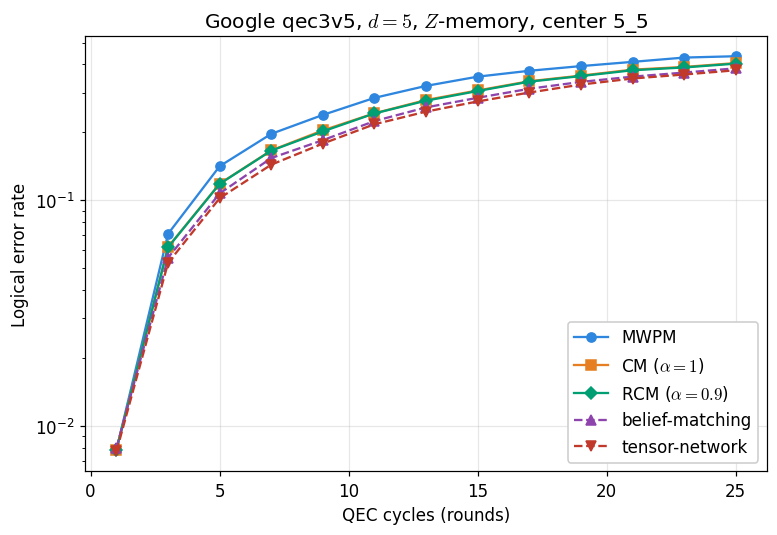

In [3]:
CACHE = os.path.join(ROOT, "data", "google_qec3v5_decoder_sweep.csv")
D, BASIS, CENTER, RCM_ALPHA = 5, "Z", "5_5", 0.9
if os.path.exists(CACHE):
    sweep = pd.read_csv(CACHE)
    print("loaded", CACHE)
else:
    rows = []
    for r in AVAILABLE_ROUNDS:
        try:
            ex = load_qec3(D, r, BASIS, CENTER)
        except FileNotFoundError:
            continue
        row = {"rounds": r, "n": ex["N"]}
        row["mwpm"] = ler(decode_cv(ex, 1.0, False), ex["act"])[0]
        row["cm"] = ler(decode_cv(ex, 1.0, True), ex["act"])[0]
        row["rcm"] = ler(decode_cv(ex, RCM_ALPHA, True), ex["act"])[0]
        for k in ("bm", "tn", "pymatching", "corr"):
            row[k] = ler(ex["google"][k], ex["act"])[0] if k in ex["google"] else np.nan
        rows.append(row); print(f"  r={r:>2}: MWPM={row['mwpm']:.3e} CM={row['cm']:.3e} "
                                 f"RCM={row['rcm']:.3e} BM={row['bm']:.3e} TN={row['tn']:.3e}")
    sweep = pd.DataFrame(rows); sweep.to_csv(CACHE, index=False); print("saved", CACHE)

fig, ax = plt.subplots(figsize=(7.2, 5.0))
series = [("mwpm", "MWPM", "#2e86de", "o", "-"),
          ("cm", r"CM ($\alpha=1$)", "#e67e22", "s", "-"),
          ("rcm", rf"RCM ($\alpha={RCM_ALPHA}$)", "#009E73", "D", "-"),
          ("bm", "belief-matching", "#8e44ad", "^", "--"),
          ("tn", "tensor-network", "#c0392b", "v", "--")]
for key, lab, c, mk, ls in series:
    ax.plot(sweep["rounds"], sweep[key], marker=mk, ls=ls, color=c, label=lab, ms=6)
ax.set_yscale("log"); ax.set_xlabel("QEC cycles (rounds)"); ax.set_ylabel(r"Logical error rate")
ax.set_title(rf"Google qec3v5, $d={D}$, $Z$-memory, center {CENTER}")
ax.legend(frameon=True, framealpha=1.0, edgecolor="0.8")
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(os.path.join(FIG, f"google_qec3v5_ler_vs_rounds_d{D}.{ext}"), bbox_inches="tight")
plt.show()

## 3. Regularized-CM $\alpha$ sweep near threshold

At the experimental (near-threshold) error rate, the theory predicts a **shallow optimum at high
$\alpha$** ($\alpha^{*}\to1$). We sweep $\alpha$ at a few round counts and plot the LER relative to
CM($\alpha=1$): RCM barely moves — confirming that near threshold there is little room to regularize
(the opposite of the deep sub-threshold regime, where low $\alpha$ wins).

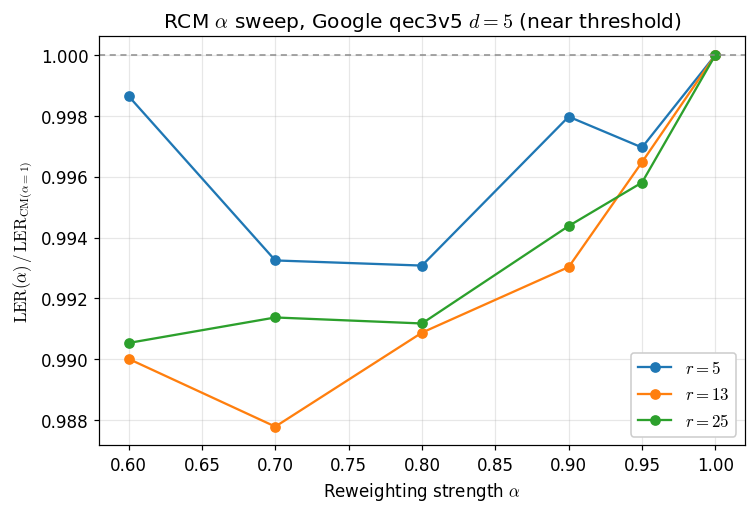

In [4]:
ALPHAS = [0.6, 0.7, 0.8, 0.9, 0.95, 1.0]
ROUNDS_A = [5, 13, 25]
fig, ax = plt.subplots(figsize=(7.0, 4.8))
for r in ROUNDS_A:
    ex = load_qec3(D, r, BASIS, CENTER)
    cm1 = ler(decode_cv(ex, 1.0, True), ex["act"])[0]
    ys = [ler(decode_cv(ex, a, True), ex["act"])[0] / cm1 for a in ALPHAS]
    ax.plot(ALPHAS, ys, marker="o", ms=6, label=rf"$r={r}$")
ax.axhline(1.0, color="0.55", lw=1.0, ls=(0, (4, 3)))
ax.set_xlabel(r"Reweighting strength $\alpha$")
ax.set_ylabel(r"$\mathrm{LER}(\alpha)\,/\,\mathrm{LER}_{\mathrm{CM}(\alpha=1)}$")
ax.set_title(rf"RCM $\alpha$ sweep, Google qec3v5 $d={D}$ (near threshold)")
ax.legend(frameon=True, framealpha=1.0, edgecolor="0.8")
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(os.path.join(FIG, f"google_qec3v5_rcm_alpha_sweep_d{D}.{ext}"), bbox_inches="tight")
plt.show()

## 4. The 105Q dataset: why the same comparison does **not** apply

`google_105Q_surface_code_d3_d5_d7` is a different beast:

1. **It is the XZZX surface code, not the standard rotated (CSS) code.** Its README states the $X$/$Z$
   basis is "an arbitrary designation for the XZZX surface code." The CSS notion of separate X-type /
   Z-type stabilizers — on which the correlated-matching hyperedge story and the coordinate-aware
   decomposition rest — does not carry over unchanged.
2. **There is no belief-matching baseline.** Its `decoding_results/` provides
   `correlated_matching` (SI1000 / RL-optimized priors), `harmony` and `libra` pathways — but **no
   belief-matching** — so a BM-vs-CM-vs-RCM comparison is impossible from the shipped data.
3. **No data-calibrated cross-validation DEMs** (only the SI1000 model DEM per pathway); the
   near-optimal calibration that makes the qec3v5 comparison fair is absent.

The fork *can* still run on the provided `error_model.dem` (it reproduces Google's CM closely), so
below is the **only** meaningful slice: CM vs RCM vs Google-CM at one 105Q experiment — **without**
belief-matching, and with the XZZX caveat. This is why the full request is done on qec3v5, not 105Q.

In [5]:
r10 = os.path.join(D105, "d5_at_q6_5", "X", "r10")
circ = stim.Circuit.from_file(os.path.join(r10, "circuit_noisy_si1000.stim"))
nd, no = circ.num_detectors, circ.num_observables
dets = _read(os.path.join(r10, "detection_events.b8"), nd, 0).astype(bool)
act = _read(os.path.join(r10, "obs_flips_actual.b8"), 0, no).astype(np.uint8).reshape(-1)
N = len(act)
pw = os.path.join(r10, "decoding_results", "correlated_matching_decoder_with_si1000_prior")
gcm = _read(os.path.join(pw, "obs_flips_predicted.b8"), 0, no).astype(np.uint8).reshape(-1)[:N]
dem = stim.DetectorErrorModel.from_file(os.path.join(pw, "error_model.dem"))
m = pymatching.Matching.from_detector_error_model(dem, enable_correlations=True)
print(f"105Q d5 (XZZX), X-basis, r10:  shots={N:,}   (NO belief-matching baseline available)\n")
print(f"{'decoder':<32}{'LER':>10}")
print("-" * 42)
print(f"{'Google CM (SI1000 prior)':<32}{ler(gcm, act)[0]:>10.4e}")
print(f"{'fork MWPM':<32}{ler(np.asarray(m.decode_batch(dets)).reshape(-1), act)[0]:>10.4e}")
print(f"{'fork CM (alpha=1)':<32}"
      f"{ler(np.asarray(m.decode_batch(dets, enable_correlations=True, alpha=1.0)).reshape(-1), act)[0]:>10.4e}")
for a in [0.95, 0.9, 0.8]:
    p = np.asarray(m.decode_batch(dets, enable_correlations=True, alpha=a)).reshape(-1)
    print(f"{'fork RCM (alpha='+str(a)+')':<32}{ler(p, act)[0]:>10.4e}")

105Q d5 (XZZX), X-basis, r10:  shots=50,000   (NO belief-matching baseline available)

decoder                                LER
------------------------------------------
Google CM (SI1000 prior)        3.8100e-02


fork MWPM                       5.5920e-02


fork CM (alpha=1)               3.9040e-02


fork RCM (alpha=0.95)           3.9220e-02


fork RCM (alpha=0.9)            3.9040e-02


fork RCM (alpha=0.8)            3.8720e-02


## Takeaways

* On the **standard rotated (CSS) surface code** experimental data (qec3v5), CM and RCM run directly
  on Google's calibrated DEMs and are directly comparable to Google's belief-matching and
  tensor-network decoders.
* **Near threshold** (the experimental regime), RCM($\alpha$ high) $\approx$ CM($\alpha=1$) — the
  regularization gives no meaningful gain here, exactly as the theory predicts ($\alpha^{*}\to1$ near
  threshold). Regularized CM's advantage is a **deep sub-threshold** phenomenon, which these
  near-threshold experiments do not probe. Belief-matching and tensor-network remain more accurate
  than all matching decoders at these high error rates.
* The **105Q** dataset is the **XZZX** code with **no belief-matching** baseline, so the requested
  three-way comparison is not applicable there; only a caveated CM-vs-RCM-vs-Google-CM slice is
  meaningful.